In [1]:
import pandas, numpy, scipy

In [2]:
import sklearn, sklearn.preprocessing, sklearn.decomposition

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

# 0. user-defined variables

In [4]:
input_file = '/Users/adrian/research/bmcbf/072_gunib/results/profiles/DESeq2_TPM_values.tsv'

# 1. read expression

In [5]:
expression = pandas.read_csv(input_file, sep='\t', index_col=0)
print(expression.shape)
expression

(39546, 18)


,C1_RD-10,C1_RD-4,C1-RD-16,C3_RD-1,C3_RD-13,C3_RD-7,KO-2_RD-14,KO-2_RD-2,KO-2_RD-8,KO-4_RD-15,KO-4_RD-3,KO-4_RD9,KO102_RD-11,KO102_RD-17,KO102_RD-5,KO104_RD-18,KO104_RD-6,KO104_RD12
ENSG00000000003.15,12.596691,14.686258,12.394477,9.573860,10.607121,9.815730,14.138058,12.020352,12.524802,9.347270,11.671931,9.309841,15.520232,17.044725,13.361358,18.950768,15.650899,16.420396
ENSG00000000005.6,0.006248,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000419.14,151.372880,150.542820,160.957369,162.605351,208.785106,180.845326,118.803821,94.260179,112.665353,179.008912,266.591498,187.072599,169.365459,169.981111,143.371055,212.509782,148.086825,169.163756
ENSG00000000457.14,5.162274,5.684001,5.175307,3.785282,3.745238,4.337197,4.891964,3.863850,4.439815,3.601391,4.415921,3.967564,5.539605,6.367274,4.884967,5.947752,4.473539,4.997530
ENSG00000000460.17,34.533652,39.894366,39.057170,20.120769,19.716557,17.580016,22.158546,17.187636,20.554335,19.552287,26.412055,17.394030,30.211959,36.527565,31.199772,28.436634,26.980345,23.527158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000291297.1,5.909471,4.126275,4.389050,3.619427,2.832095,4.094245,3.108727,4.001798,3.256649,2.841205,1.792586,4.229013,6.650977,5.296973,5.108045,4.641987,3.210713,5.599468
ENSG00000291298.1,0.000000,0.000000,0.000000,0.082729,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291299.1,2.017005,1.167282,1.622340,1.627860,1.043391,1.120911,0.967853,1.316918,1.466600,1.312401,0.185709,0.731063,1.736952,1.896286,1.282753,1.708880,1.560892,1.875593
ENSG00000291300.1,0.000000,0.027563,0.000000,0.000000,0.000000,0.000000,0.000000,0.030609,0.003115,0.003770,0.000000,0.003252,0.000000,0.000000,0.000000,0.000000,0.013566,0.006578


In [6]:
for element in expression.columns:
    print(element)

C1_RD-10
C1_RD-4
C1-RD-16
C3_RD-1
C3_RD-13
C3_RD-7
KO-2_RD-14
KO-2_RD-2
KO-2_RD-8
KO-4_RD-15
KO-4_RD-3
KO-4_RD9
KO102_RD-11
KO102_RD-17
KO102_RD-5
KO104_RD-18
KO104_RD-6
KO104_RD12


# 3. filter and transform

In [7]:
substantial_expression = expression[expression.max(axis=1) >= 2]
high_expression = expression[expression.max(axis=1) >= 100]

print(substantial_expression.shape)
print(high_expression.shape)

(14515, 18)
(2620, 18)


In [8]:
transpose = substantial_expression.transpose()
pca_substantial_expression = numpy.log2(transpose + 1)

transpose = high_expression.transpose()
pca_high_expression = numpy.log2(transpose + 1)

# 4. visualize substantial expression

In [9]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_substantial_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.51069515 0.18283696]


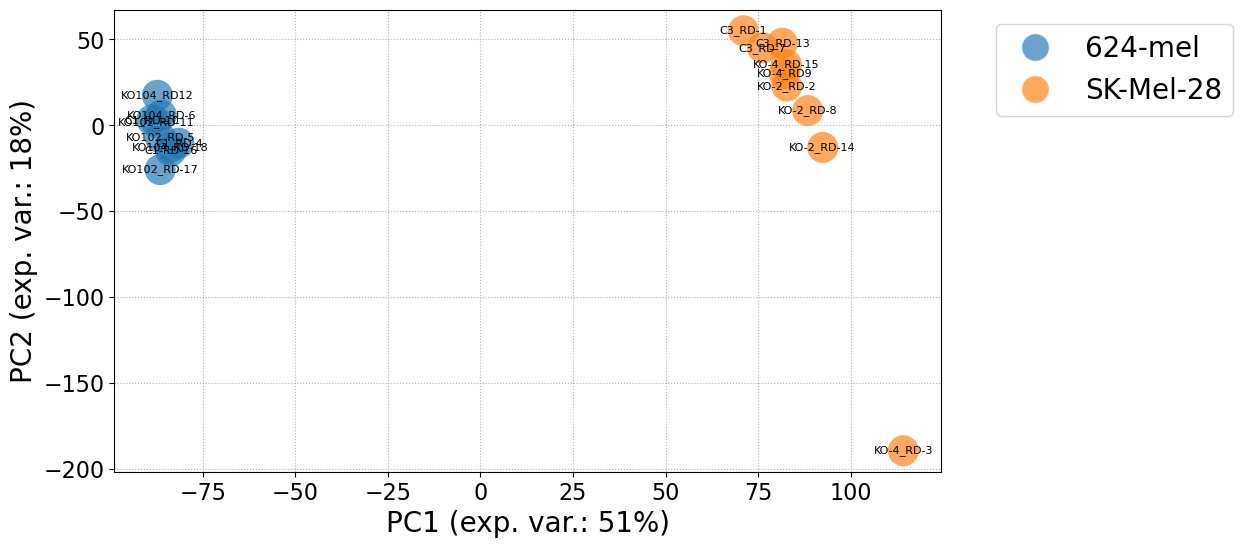

In [10]:
for i in range(len(new)):

    name = expression.columns[i]

    # colors
    if ('C1' in name) | ('KO102' in name) | ('KO104' in name):
        the_color = 'tab:blue'
    elif ('C3' in name) | ('KO-2' in name) | ('KO-4' in name):
        the_color = 'tab:orange'
    else:
        print(name)
        print('error')

    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=500, c=the_color, marker='o', alpha=2/3, edgecolors='none')
    epsilon = 0
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, name, size=8, va='center', ha='center')

legend_elements = [
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:blue', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:orange', markeredgecolor='white', markersize=20, alpha=2/3),
]

matplotlib.pyplot.legend(legend_elements, ['624-mel', 'SK-Mel-28'], ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))

matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.show()

# 4. visualize high expression

In [11]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_high_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.54925845 0.17189468]


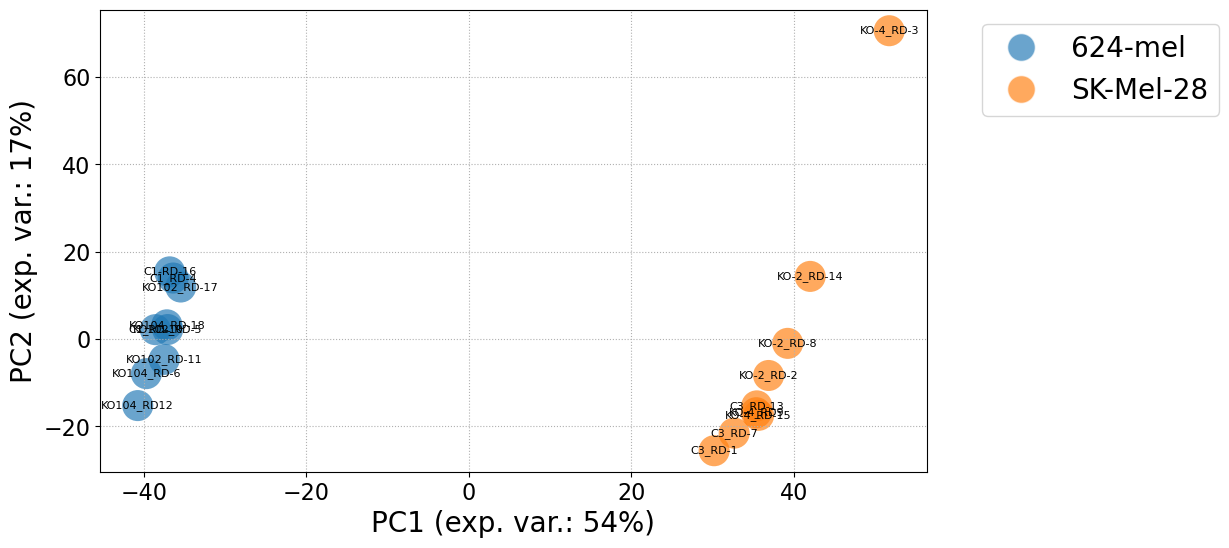

In [12]:
for i in range(len(new)):

    name = expression.columns[i]

    # colors
    if ('C1' in name) | ('KO102' in name) | ('KO104' in name):
        the_color = 'tab:blue'
    elif ('C3' in name) | ('KO-2' in name) | ('KO-4' in name):
        the_color = 'tab:orange'
    else:
        print(name)
        print('error')

    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=500, c=the_color, marker='o', alpha=2/3, edgecolors='none')
    epsilon = 0
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, name, size=8, va='center', ha='center')

legend_elements = [
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:blue', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:orange', markeredgecolor='white', markersize=20, alpha=2/3),
]

matplotlib.pyplot.legend(legend_elements, ['624-mel', 'SK-Mel-28'], ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))

matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.show()

In [13]:
# 5. distributions

In [14]:
log2_tpm_PO = numpy.log2(expression + 1)
log2_tpm_PO.head()

,C1_RD-10,C1_RD-4,C1-RD-16,C3_RD-1,C3_RD-13,C3_RD-7,KO-2_RD-14,KO-2_RD-2,KO-2_RD-8,KO-4_RD-15,KO-4_RD-3,KO-4_RD9,KO102_RD-11,KO102_RD-17,KO102_RD-5,KO104_RD-18,KO104_RD-6,KO104_RD12
ENSG00000000003.15,3.765184,3.971429,3.743566,3.402430,3.536938,3.435059,3.920108,3.702697,3.757536,3.371178,3.663564,3.365950,4.046162,4.173505,3.844120,4.318372,4.057528,4.122705
ENSG00000000005.6,0.008986,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000419.14,7.251462,7.243582,7.339470,7.354076,7.712768,7.506568,6.904530,6.573801,6.828649,7.491925,8.063888,7.555146,7.412489,7.417693,7.173638,7.738158,7.220009,7.410780
ENSG00000000457.14,2.623463,2.740712,2.626511,2.258604,2.246480,2.416082,2.558749,2.282099,2.443558,2.202070,2.437207,2.312539,2.709204,2.881131,2.557034,2.796546,2.452474,2.584368
ENSG00000000460.17,5.151114,5.353830,5.323989,4.400590,4.372712,4.215680,4.533473,4.184886,4.429906,4.361227,4.776739,4.201166,4.964027,5.229879,5.008979,4.879541,4.806342,4.616308


141
14.046894961522685


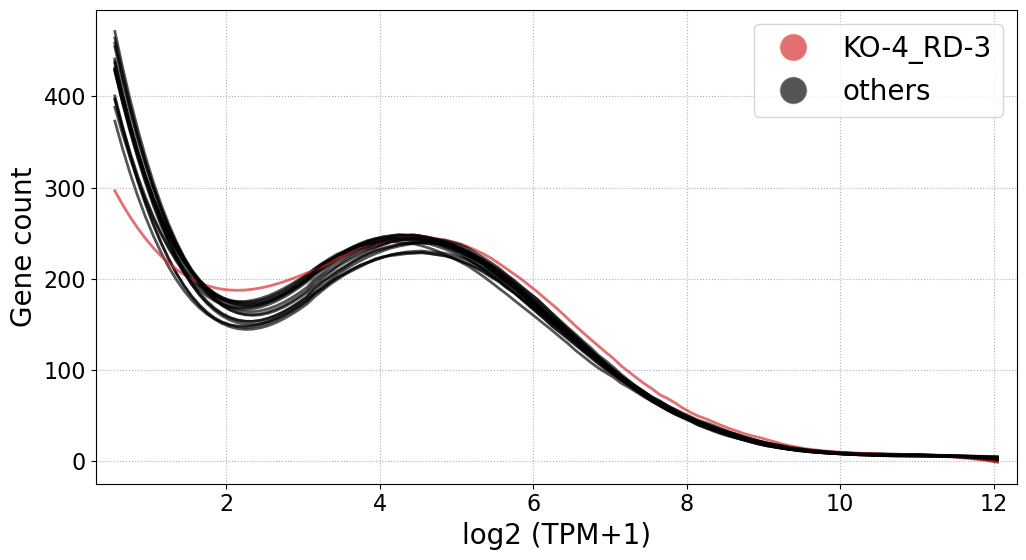

In [15]:
found_max = 14.1
number_of_bins = int(found_max*10)
print(number_of_bins)

absolute_max = 0
working_samples = log2_tpm_PO.columns.to_list()

most_likely_expressions = []
all_hats = []
for i in range(len(working_samples)):

    name = working_samples[i]

    ## colors
    if 'KO-4_RD-3' in name:
        the_color = 'tab:red'
    else:
        the_color = 'black'
    
    log2TPM = log2_tpm_PO.loc[:, name]
    if max(log2TPM) > absolute_max:
        absolute_max = max(log2TPM)
                
    hist, bin_edges = numpy.histogram(log2TPM, bins=number_of_bins, range=(0, found_max))
    half_bin = (bin_edges[1] - bin_edges[0])/2
    x = bin_edges + half_bin
    x = x[:-1]
  
    plotting_x = x[5:-20]
    plotting_hist = hist[5:-20]
    #print(plotting_x)
    
    #matplotlib.pyplot.plot(plotting_x, plotting_hist, 'o', alpha=1/5, mec='none', color=the_color)
    yhat = scipy.signal.savgol_filter(plotting_hist, 51, 3)

    matplotlib.pyplot.plot(plotting_x, yhat, '-', lw=2, alpha=2/3, color=the_color)
    
matplotlib.pyplot.xlim([numpy.min(plotting_x)-0.25, numpy.max(plotting_x)+0.25])
#matplotlib.pyplot.ylim([0, 400])

legend_elements = [
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:red', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='black', markeredgecolor='white', markersize=20, alpha=2/3),
]

matplotlib.pyplot.legend(legend_elements, ['KO-4_RD-3', 'others'], ncol=1, loc='upper right')

matplotlib.pyplot.xlabel('log2 (TPM+1)')
matplotlib.pyplot.ylabel('Gene count')
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.tight_layout()

print(absolute_max)

In [16]:
# lets see the effect of KOs in each cell type
expression_624 = []
expression.columns

Index(['C1_RD-10', 'C1_RD-4', 'C1-RD-16', 'C3_RD-1', 'C3_RD-13', 'C3_RD-7',
       'KO-2_RD-14', 'KO-2_RD-2', 'KO-2_RD-8', 'KO-4_RD-15', 'KO-4_RD-3',
       'KO-4_RD9', 'KO102_RD-11', 'KO102_RD-17', 'KO102_RD-5', 'KO104_RD-18',
       'KO104_RD-6', 'KO104_RD12'],
      dtype='object')

['C1_RD-10', 'C1_RD-4', 'C1-RD-16', 'KO102_RD-11', 'KO102_RD-17', 'KO102_RD-5', 'KO104_RD-18', 'KO104_RD-6', 'KO104_RD12']
(2004, 9)
[0.43610752 0.25210205]


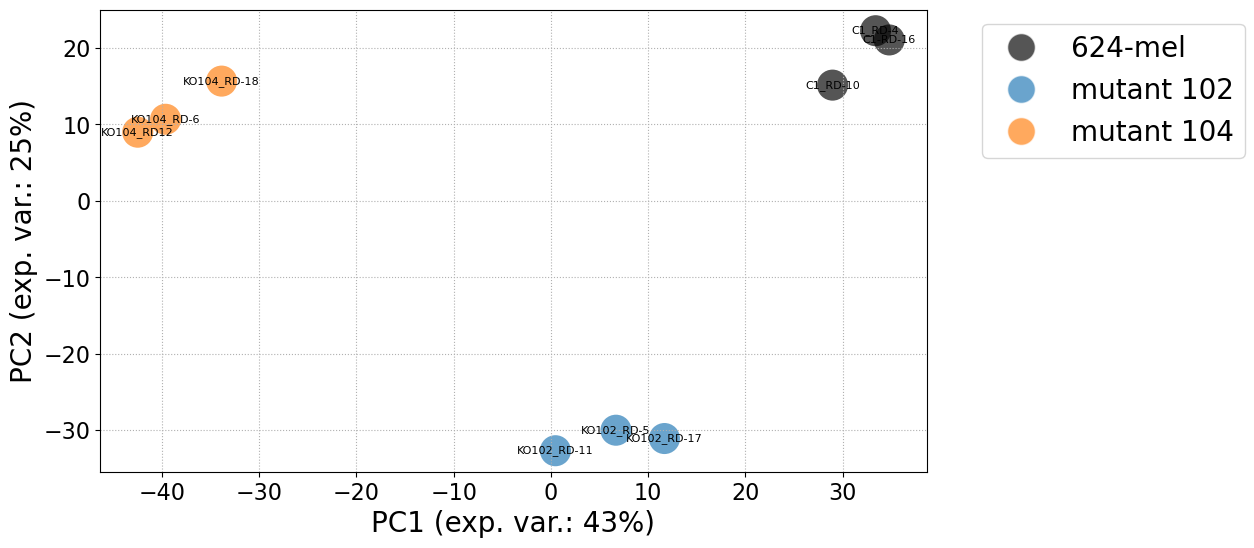

In [17]:
working_tags = [tag for tag in expression.columns if ('C1' in tag) or ('KO102' in tag) or ('KO104' in tag)]
print(working_tags)
expression_624 = expression.loc[:, working_tags]

high_expression = expression_624[expression_624.max(axis=1) >= 100]
print(high_expression.shape)

transpose = high_expression.transpose()
pca_high_expression = numpy.log2(transpose + 1)

scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_high_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

for i in range(len(new)):

    name = expression_624.columns[i]

    # colors
    if 'C1' in name:
        the_color = 'black'
    elif 'KO102' in name:
        the_color = 'tab:blue'
    elif 'KO104' in name:
        the_color = 'tab:orange'
    else:
        print(name)
        print('error')

    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=500, c=the_color, marker='o', alpha=2/3, edgecolors='none')
    epsilon = 0
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, name, size=8, va='center', ha='center')

legend_elements = [
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='black', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:blue', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:orange', markeredgecolor='white', markersize=20, alpha=2/3),
]

matplotlib.pyplot.legend(legend_elements, ['624-mel', 'mutant 102', 'mutant 104'], ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))

matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.show()

['C3_RD-1', 'C3_RD-13', 'C3_RD-7', 'KO-2_RD-14', 'KO-2_RD-2', 'KO-2_RD-8', 'KO-4_RD-15', 'KO-4_RD-3', 'KO-4_RD9']
(2221, 9)
[0.540265   0.17628896]


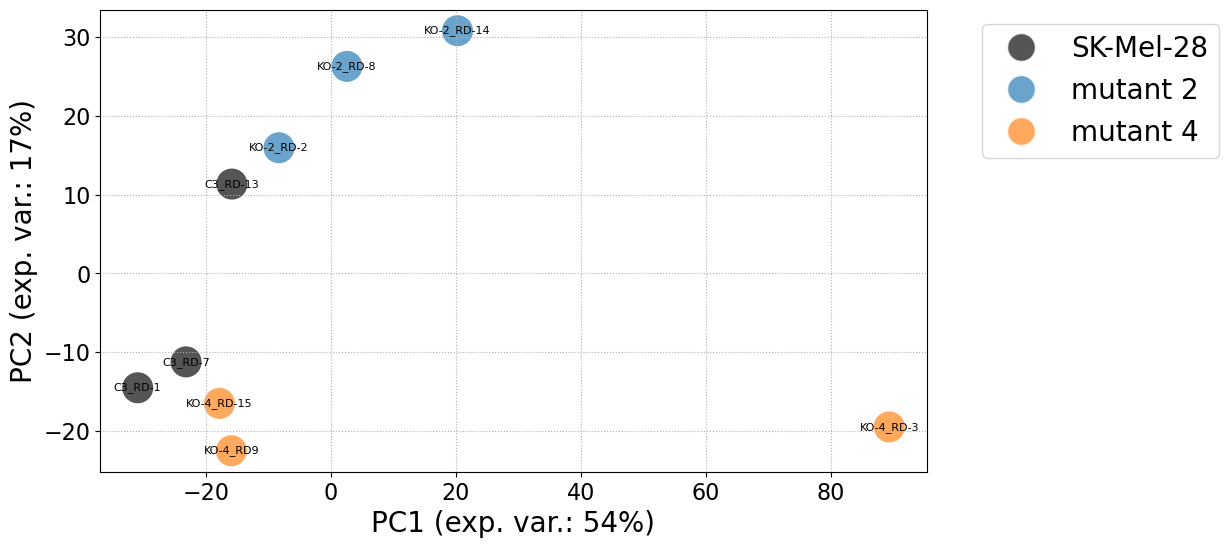

In [18]:
working_tags = [tag for tag in expression.columns if ('C3' in tag) or ('KO-2' in tag) or ('KO-4' in tag)]
print(working_tags)
expression_28 = expression.loc[:, working_tags]

high_expression = expression_28[expression_28.max(axis=1) >= 100]
print(high_expression.shape)

transpose = high_expression.transpose()
pca_high_expression = numpy.log2(transpose + 1)

scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_high_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

for i in range(len(new)):

    name = expression_28.columns[i]

    # colors
    if 'C3' in name:
        the_color = 'black'
    elif 'KO-2' in name:
        the_color = 'tab:blue'
    elif 'KO-4' in name:
        the_color = 'tab:orange'
    else:
        print(name)
        print('error')

    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=500, c=the_color, marker='o', alpha=2/3, edgecolors='none')
    epsilon = 0
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, name, size=8, va='center', ha='center')

legend_elements = [
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='black', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:blue', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:orange', markeredgecolor='white', markersize=20, alpha=2/3),
]

matplotlib.pyplot.legend(legend_elements, ['SK-Mel-28', 'mutant 2', 'mutant 4'], ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))

matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.show()